In [1]:
import zipfile
from google.colab import files
import os

print("Please upload your zipped image dataset folder (e.g., 'images.zip').")

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  # Assuming the uploaded file is a zip archive
  try:
    with zipfile.ZipFile(fn, 'r') as zip_ref:
      zip_ref.extractall(os.path.join(os.getcwd(), 'dataset')) # Extract to a 'dataset' folder
    print(f'Successfully extracted "{fn}" to the "dataset" folder.')
  except zipfile.BadZipFile:
    print(f'Error: "{fn}" is not a valid zip file. Please upload a zip archive.')
  except Exception as e:
    print(f'An unexpected error occurred: {e}')

# List the contents of the created 'dataset' folder to confirm
if os.path.exists('dataset'):
  print('\nContents of the \'dataset\' folder:')
  for root, dirs, files in os.walk('dataset'):
    level = root.replace('dataset', '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
      print(f'{subindent}{f}')
else:
  print('\nNo \'dataset\' folder was created.')

Please upload your zipped image dataset folder (e.g., 'images.zip').


Saving Flower_Dataset.zip to Flower_Dataset.zip
User uploaded file "Flower_Dataset.zip" with length 215160703 bytes
Successfully extracted "Flower_Dataset.zip" to the "dataset" folder.

Contents of the 'dataset' folder:
dataset/
    Flower_Dataset/
        train/
            tulip/
                8622237974_b362574785_n.jpg
                8523133474_d2c0845b54.jpg
                12025038686_7f10811d4b_n.jpg
                14067476586_36bcddf111.jpg
                14067761295_7cfe6a42e9.jpg
                13888320717_d2919a879b_m.jpg
                5810456385_b44358a0ae.jpg
                4520582070_d14a14f038.jpg
                4553203984_9cb9312240_n.jpg
                14266093711_66d18a1e44_n.jpg
                8712282563_3819afb7bc.jpg
                17198868382_697b23c715_n.jpg
                14068348874_7b36c99f6a.jpg
                12024561754_ce9667e4dc_n.jpg
                14087425312_2b5846b570_n.jpg
                6958243974_8851425ddb_n.jpg
                45

In [2]:
import tensorflow as tf

# Check GPU status
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU not found. Please go to Runtime -> Change runtime type and select GPU.')
else:
  print(f'Found GPU at: {device_name}')

!nvidia-smi

Found GPU at: /device:GPU:0
Sun May 24 03:23:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             26W /   70W |     105MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-------------------

In [6]:
import os

# Check the subdirectory structure in the dataset folder
print(f"Checking path: {DATASET_PATH}")
subdirs = [d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))]
print(f"Found subdirectories: {subdirs}")

for subdir in subdirs:
    path = os.path.join(DATASET_PATH, subdir)
    classes = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
    print(f"\nSub-folder '{subdir}' contains {len(classes)} classes: {classes}")

    # Count images per class
    for cls in classes:
        img_count = len(os.listdir(os.path.join(path, cls)))
        print(f" - Class '{cls}': {img_count} images")

print("\nNOTE: If 'Found 1 classes' appeared during training, ensure your images are inside subfolders named after their labels (e.g., dataset/roses/img1.jpg, dataset/tulips/img2.jpg).")

Checking path: dataset
Found subdirectories: ['Flower_Dataset']

Sub-folder 'Flower_Dataset' contains 2 classes: ['train', 'test']
 - Class 'train': 5 images
 - Class 'test': 924 images

NOTE: If 'Found 1 classes' appeared during training, ensure your images are inside subfolders named after their labels (e.g., dataset/roses/img1.jpg, dataset/tulips/img2.jpg).


In [10]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

# Updated path to the actual training folder
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 25
# The path should point to where the class subfolders (e.g., tulip) are
DATASET_PATH = 'dataset/Flower_Dataset/train'

# Data Preparation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Rebuild Model for correct number of classes
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Retrain
if train_generator.num_classes > 1:
    with tf.device('/GPU:0'):
        history = model.fit(
            train_generator,
            validation_data=val_generator,
            epochs=EPOCHS
        )
else:
    print('Error: Still only found 1 class. Check if the subfolders exist in', DATASET_PATH)

Found 2198 images belonging to 5 classes.
Found 548 images belonging to 5 classes.
Epoch 1/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 355s 3s/step - accuracy: 0.7157 - loss: 0.8102 - val_accuracy: 0.3175 - val_loss: 26.7068
Epoch 2/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 42s 608ms/step - accuracy: 0.8289 - loss: 0.4783 - val_accuracy: 0.5876 - val_loss: 3.3534
Epoch 3/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 42s 607ms/step - accuracy: 0.8549 - loss: 0.3911 - val_accuracy: 0.6788 - val_loss: 1.9144
Epoch 4/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 42s 605ms/step - accuracy: 0.8708 - loss: 0.3465 - val_accuracy: 0.6040 - val_loss: 2.1688
Epoch 5/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 43s 617ms/step - accuracy: 0.8958 - loss: 0.2971 - val_accuracy: 0.7354 - val_loss: 1.3869
Epoch 6/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 42s 612ms/step - accuracy: 0.8963 - loss: 0.2950 - val_accuracy: 0.8412 - val_loss: 0.5207
Epoch 7/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 42s 610ms/step - accuracy: 0.9054 - loss: 0.2617 - val_accuracy: 0.7299 - val_loss: 0.9569
Epoch 8/25
69/6

In [11]:
# Summarize training results
final_loss, final_accuracy = model.evaluate(val_generator)
print(f"\n--- SUMMARY ---")
print(f"Final Validation Accuracy: {final_accuracy*100:.2f}%")
print(f"Final Validation Loss: {final_loss:.4f}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 383ms/step - accuracy: 0.8522 - loss: 0.5560

--- SUMMARY ---
Final Validation Accuracy: 85.22%
Final Validation Loss: 0.5560


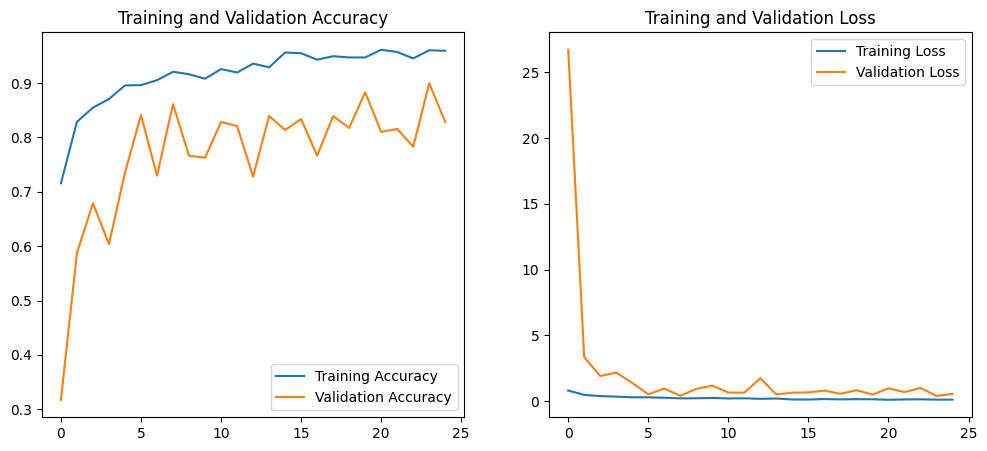

In [12]:
import matplotlib.pyplot as plt

# Display training plots
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()